### Лабораторная работа №5

#### Импорты / настройки

In [154]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

In [155]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

#### Подготовка данных

In [156]:
train_dataset_search_param = CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())

100.0%
c:\projects\pstu-machine-learning-models-and-technologies\lab_work_5\src\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [157]:
# Размер для масштабирования картинок
RESCALE_SIZE_CIFAR10 = [train_dataset_search_param.data.shape[1], train_dataset_search_param.data.shape[2]]
BATCH_SIZE = 64

In [158]:
train_loader_search_param = DataLoader(train_dataset_search_param, batch_size=BATCH_SIZE, shuffle=False)

Расчитаем mean и std для CIFAR10 ([stackoverflow](https://stackoverflow.com/questions/60101240/finding-mean-and-standard-deviation-across-image-channels-pytorch))

In [159]:
print('Расчет mean и std для CIFAR10...')
nimages = 0
mean = torch.zeros(3)
std = torch.zeros(3)
for batch, _ in tqdm(train_loader_search_param):
    # batch: [batch, channels, height, width] -> [64, 3, 32, 32]
    batch = batch.view(batch.size(0), batch.size(1), -1) # [64, 3, 32 * 32]
    # Cчитаем количество изображений в батче
    nimages += batch.size(0)
    # Cчитаем среднее для каждого канала, считаем сумму по всем каналам
    mean += batch.mean(2).sum(0)
    # Cчитаем стандартное отклоенение для каждого канала, считаем сумму по всем каналам
    std += batch.std(2).sum(0)

Расчет mean и std для CIFAR10...


100%|██████████| 782/782 [00:06<00:00, 125.20it/s]


In [160]:
NORMALIZE_MEAN_CIFAR10 = mean / nimages
NORMALIZE_STD_CIFAR10 = std / nimages

In [161]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN_CIFAR10, NORMALIZE_STD_CIFAR10)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN_CIFAR10, NORMALIZE_STD_CIFAR10)
])

Посмотрим на дисбаланс классов

In [162]:
target_counter = Counter(train_dataset_search_param.targets)
target_counter

Counter({6: 5000,
         9: 5000,
         4: 5000,
         1: 5000,
         2: 5000,
         7: 5000,
         8: 5000,
         3: 5000,
         5: 5000,
         0: 5000})

In [163]:
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)

In [164]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [165]:
def show_images(dataset, n_rows=2, n_cols=2, normalized=True) -> None:
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    # Цикл повторяется (n_rows * n_cols) раз
    for fig_x in ax.flatten():
        idx = int(np.random.uniform(0, len(dataset)))
        img_tensor, img_target = dataset[idx]
        img_numpy = img_tensor.numpy().transpose(1, 2, 0) # [C, H, W] -> [H, W, C]
        if not normalized:
            # Обратная нормализация (оригинал по цвету)
            img_numpy = NORMALIZE_STD_CIFAR10 * img_numpy + NORMALIZE_MEAN_CIFAR10
        img_class = dataset.classes[img_target]
        fig_x.imshow(img_numpy)
        fig_x.set_title(f'{img_class} ({img_target})')
    fig.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.4223638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.676046].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.1457663].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..1.5247186].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.3396146].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.2814603].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555

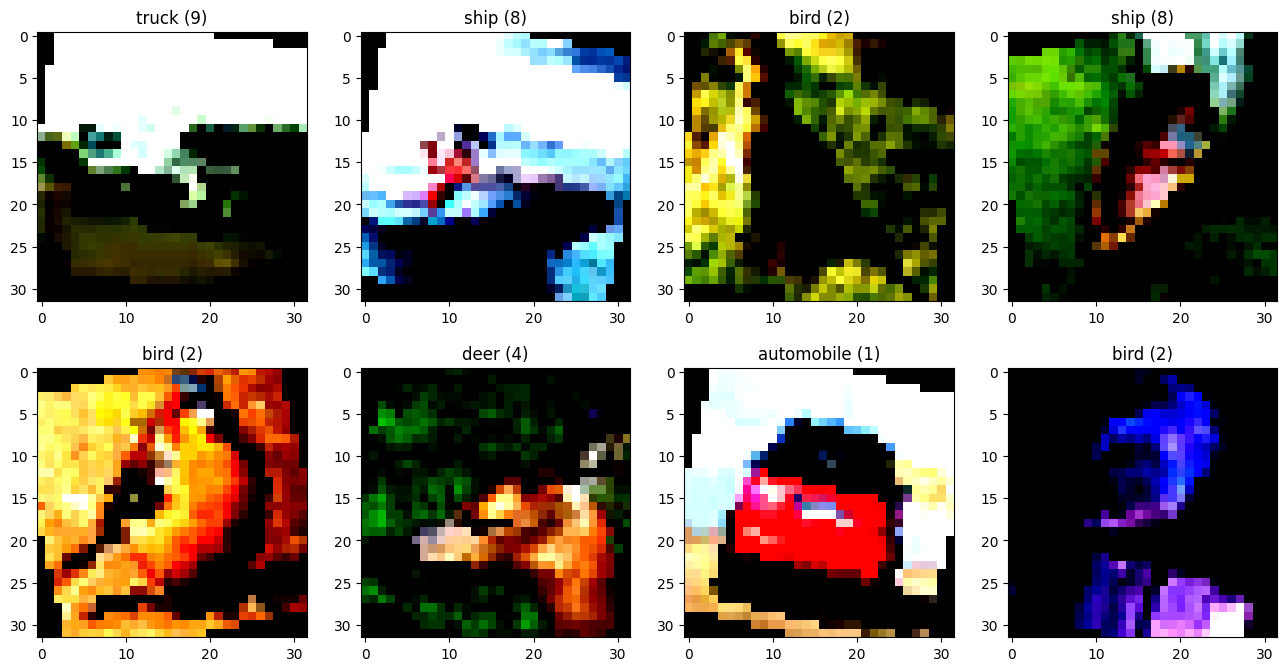

In [166]:
show_images(train_dataset, 2, 4, True)

#### Ручная реализация CNN